# Dataset Investigation for Improved NLP Pipeline

## Objective

The baseline machine learning models achieved limited predictive performance for Ticket Priority classification.

The objective of this notebook is to investigate the dataset in detail to identify potential data quality issues, understand feature distributions, detect noisy or duplicated data, and determine whether the dataset is suitable for building a more advanced NLP pipeline.

The findings from this notebook will guide the design of the next-generation text preprocessing and modeling approach.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

## Load Customer Support Dataset

In [2]:
data_path = Path("../data/raw/customer_support_tickets.csv")

df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciate that you have requested a website address.\n\nPlease double check your email a...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchased}. Please assist.\n\nIf you need to change an existing product.\n\nI'm having an issue with the {product_purchased}. Please assist.\n\nIf The issue I...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\n\n1.8.3 I really I'm using the origin...",Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,"I'm having an issue with the {product_purchased}. Please assist.\n\nIf you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've already contacte...",Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchased}. Please assist.\n\n\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## Dataset Structure

Understanding the dataset structure is the first step in evaluating data quality.

This section examines:

- Number of rows and columns
- Data types
- Missing values
- Memory usage

These observations help identify potential preprocessing requirements before model development.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

## Dataset Columns

The following section lists all available features in the dataset.

This helps identify:

- Text features
- Categorical features
- Numerical features
- Candidate target variables

In [4]:
df.columns.tolist()

['Ticket ID',
 'Customer Name',
 'Customer Email',
 'Customer Age',
 'Customer Gender',
 'Product Purchased',
 'Date of Purchase',
 'Ticket Type',
 'Ticket Subject',
 'Ticket Description',
 'Ticket Status',
 'Resolution',
 'Ticket Priority',
 'Ticket Channel',
 'First Response Time',
 'Time to Resolution',
 'Customer Satisfaction Rating']

## Statistical Summary

A statistical summary provides an overview of numerical and categorical variables.

This helps detect:

- Unusual values
- Constant columns
- Data distribution
- Potential anomalies

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticket ID,8469.0,NaN,NaN,NaN,4235.0,2444.934048,1.0,2118.0,4235.0,6352.0,8469.0
Customer Name,8469,8028,Michael Garcia,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Email,8469,8320,asmith@example.com,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Age,8469.0,NaN,NaN,NaN,44.026804,15.296112,18.0,31.0,44.0,57.0,70.0
Customer Gender,8469,3,Male,2896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Purchased,8469,42,Canon EOS,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Purchase,8469,730,2020-10-21,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket Type,8469,5,Refund request,1752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket Subject,8469,16,Refund request,576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket Description,8469,8077,I'm having an issue with the {product_purchased}. Please assist. This problem started occurring after the recent software update. I haven't made any other changes to the device.,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Value Analysis

Missing values can negatively impact machine learning models.

This section verifies whether the dataset contains incomplete records that require preprocessing or imputation.

In [6]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

Customer Satisfaction Rating    5700
Resolution                      5700
Time to Resolution              5700
First Response Time             2819
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Ticket Subject                     0
Ticket Type                        0
Date of Purchase                   0
Product Purchased                  0
Ticket Priority                    0
Ticket Status                      0
Ticket Description                 0
Ticket Channel                     0
dtype: int64

## Missing Value Assessment

The dataset contains several columns with a significant number of missing values.

These missing values are not random. They represent information that becomes available only after the ticket has progressed through the support workflow.

For example:

- Resolution
- Time to Resolution
- Customer Satisfaction Rating

These columns are unavailable when a new ticket is created and therefore should not be used for real-time ticket priority prediction.

Using such features would introduce data leakage and produce unrealistic model performance.

## Duplicate Record Analysis

Duplicate records can introduce bias during model training and evaluation.

This section investigates whether identical support tickets exist within the dataset.

In [7]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


In [8]:
df["Ticket Text"] = (
    df["Ticket Subject"].fillna("")
    + " "
    + df["Ticket Description"].fillna("")
)

duplicate_ticket_text = df["Ticket Text"].duplicated().sum()

print(f"Duplicate Ticket Text: {duplicate_ticket_text}")

Duplicate Ticket Text: 144


In [9]:
duplicates = df[df["Ticket Text"].duplicated(keep=False)]

duplicates[
    [
        "Ticket Subject",
        "Ticket Priority",
        "Ticket Text",
    ]
].head(10)

,Ticket Subject,Ticket Priority,Ticket Text
56,Software bug,Medium,Software bug I'm having an issue with the {product_purchased}. Please assist. I've noticed that the issue occurs consistently when I use a specific feature or application on my {product_purchased}.
80,Product recommendation,Critical,Product recommendation I'm having an issue with the {product_purchased}. Please assist. I'm unable to find the option to perform the desired action in the {product_purchased}. Could you please gui...
105,Battery life,Critical,Battery life I'm having an issue with the {product_purchased}. Please assist. I need assistance as soon as possible because it's affecting my work and productivity.
107,Account access,High,"Account access I'm having an issue with the {product_purchased}. Please assist. I've checked for software updates, and my {product_purchased} is already running the latest version."
224,Network problem,Medium,"Network problem I'm having an issue with the {product_purchased}. Please assist. I'm experiencing this issue on multiple devices of the same model, so it seems to be a widespread problem."
257,Hardware issue,High,"Hardware issue I'm having an issue with the {product_purchased}. Please assist. I've checked for software updates, and my {product_purchased} is already running the latest version."
267,Product recommendation,Low,Product recommendation I'm having an issue with the {product_purchased}. Please assist. I'm concerned about the security of my {product_purchased} and would like to ensure that my data is safe.
273,Hardware issue,High,Hardware issue I'm having an issue with the {product_purchased}. Please assist. I've noticed a peculiar error message popping up on my {product_purchased} screen. It says '{error_message}'. What d...
290,Payment issue,Low,"Payment issue I'm having an issue with the {product_purchased}. Please assist. I've tried using different cables, adapters, or peripherals with my {product_purchased}, but the issue persists."
291,Data loss,High,Data loss I'm having an issue with the {product_purchased}. Please assist. I need assistance as soon as possible because it's affecting my work and productivity.


## Duplicate Text Assessment

The dataset contains duplicate ticket texts despite having no fully duplicated records.

This suggests that portions of the dataset are generated from reusable templates rather than unique customer conversations.

While duplicate ticket text is not inherently problematic, extensive reuse of templates reduces textual diversity and may limit the ability of machine learning models to learn discriminative language patterns.

## Placeholder Token Analysis

Several ticket examples observed during the baseline investigation contained placeholder tokens such as `{product_purchased}`.

Placeholder values reduce semantic information and may negatively affect text-based machine learning models.

This section measures the prevalence of common placeholder patterns within the dataset.

In [10]:
placeholders = [
    "{product_purchased}",
    "{error_message}"
]

for placeholder in placeholders:
    count = df["Ticket Text"].str.contains(
        placeholder,
        case=False,
        regex=False
    ).sum()

    print(f"{placeholder}: {count}")

{product_purchased}: 8469
{error_message}: 472


## Text Length Analysis

Understanding the distribution of ticket lengths helps identify unusually short, excessively long, or inconsistent ticket descriptions that may affect feature extraction and model performance.

In [11]:
df["Text Length"] = df["Ticket Text"].str.len()

df["Text Length"].describe()

count    8469.000000
mean      306.546818
std        43.809154
min       161.000000
25%       289.000000
50%       315.000000
75%       335.000000
max       414.000000
Name: Text Length, dtype: float64

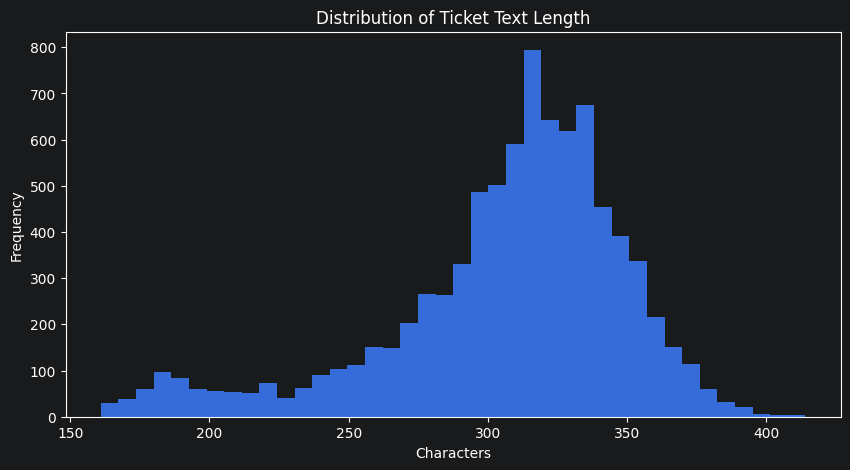

In [15]:
plt.figure(figsize=(10,5))

plt.hist(df["Text Length"], bins=40)

plt.title("Distribution of Ticket Text Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()



## Relationship Between Ticket Subject and Ticket Priority

This section investigates whether particular ticket subjects are strongly associated with specific priority levels.

If certain subjects consistently map to one priority, they may provide highly informative predictive features.

In [16]:
pd.crosstab(
    df["Ticket Subject"],
    df["Ticket Priority"]
)

Ticket Priority,Critical,High,Low,Medium
Ticket Subject,,,,
Account access,113,130,131,135
Battery life,124,134,133,151
Cancellation request,126,118,119,124
Data loss,128,128,110,125
Delivery problem,127,150,128,156
Display issue,120,121,112,125
Hardware issue,155,130,152,110
Installation support,129,142,129,130
Network problem,142,131,130,136


In [17]:
subject_priority = (
    pd.crosstab(
        df["Ticket Subject"],
        df["Ticket Priority"],
        normalize="index"
    ) * 100
)

subject_priority.round(2)

Ticket Priority,Critical,High,Low,Medium
Ticket Subject,,,,
Account access,22.20,25.54,25.74,26.52
Battery life,22.88,24.72,24.54,27.86
Cancellation request,25.87,24.23,24.44,25.46
Data loss,26.07,26.07,22.40,25.46
Delivery problem,22.64,26.74,22.82,27.81
Display issue,25.10,25.31,23.43,26.15
Hardware issue,28.34,23.77,27.79,20.11
Installation support,24.34,26.79,24.34,24.53
Network problem,26.35,24.30,24.12,25.23


## Keyword Frequency Analysis

This section investigates whether specific urgency-related words occur more frequently in higher-priority tickets.

If strong keyword patterns exist, they may provide useful predictive signals for the improved NLP pipeline.

In [18]:
keywords = [
    "urgent",
    "immediately",
    "as soon as possible",
    "critical",
    "important",
    "emergency",
]

for word in keywords:
    print(f"\nKeyword: {word}")

    print(
        df[df["Ticket Text"]
            .str.contains(word, case=False, na=False)]
        ["Ticket Priority"]
        .value_counts()
    )


Keyword: urgent
Ticket Priority
High        47
Low         40
Critical    40
Medium      39
Name: count, dtype: int64

Keyword: immediately
Ticket Priority
Critical    9
High        9
Low         7
Medium      6
Name: count, dtype: int64

Keyword: as soon as possible
Ticket Priority
High        145
Medium      140
Critical    123
Low         101
Name: count, dtype: int64

Keyword: critical
Ticket Priority
Low     1
High    1
Name: count, dtype: int64

Keyword: important
Ticket Priority
High        57
Critical    52
Medium      50
Low         43
Name: count, dtype: int64

Keyword: emergency
Ticket Priority
Critical    1
High        1
Name: count, dtype: int64


# Investigating Priority-Specific Keywords

A common assumption is that higher priority tickets contain stronger urgency words such as
"urgent", "immediately", "critical", or "emergency".

This experiment checks whether these keywords actually correlate with the assigned ticket priority.

## Observation

The keyword analysis shows that urgency-related words are distributed across all four priority classes.

Examples:

- "urgent" appears almost equally in every priority.
- "as soon as possible" is present in High, Medium, Critical and Low tickets.
- Even the word "critical" barely appears.
- "emergency" occurs only twice in the entire dataset.

This indicates that the dataset does not use urgency vocabulary to determine ticket priority.

## Conclusion

The ticket text alone does not provide reliable linguistic signals for predicting priority.

Instead, the dataset appears to assign priorities independently of the written language.

Therefore, simply improving NLP preprocessing (cleaning text, TF-IDF tuning, stopword removal, stemming, lemmatization, etc.) is unlikely to produce a significant improvement in model performance.

This confirms the findings from the baseline experiments where multiple machine learning models achieved only random-like performance.

# Investigating Duplicate Ticket Text with Different Priorities

If the same ticket text appears multiple times but is assigned different priority labels, then the relationship between ticket text and ticket priority is inconsistent.

Such inconsistencies make it impossible for a machine learning model to learn a deterministic mapping from text to priority.

This experiment identifies duplicate ticket texts that have been assigned multiple priority labels.

In [19]:
text_col = "Ticket Description"

duplicate_texts = (
    df.groupby(text_col)["Ticket Priority"]
      .nunique()
      .sort_values(ascending=False)
)

duplicate_texts.head(10)

Ticket Description
I'm having an issue with the {product_purchased}. Please assist. I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.                                  4
I'm having an issue with the {product_purchased}. Please assist. I've checked the device settings and made sure that everything is configured correctly.                                                 4
I'm having an issue with the {product_purchased}. Please assist. I've noticed a peculiar error message popping up on my {product_purchased} screen. It says '{error_message}'. What does it mean?        4
I'm having an issue with the {product_purchased}. Please assist. I need assistance as soon as possible because it's affecting my work and productivity.                                                  4
I'm having an issue with the {product_purchased}. Please assist. I rely heavily on my {product_purchased} for my daily tasks, and this issue is hindering my productivity

In [20]:
duplicate_texts = duplicate_texts[duplicate_texts > 1]

print("Duplicate ticket descriptions with multiple priorities:")
print(len(duplicate_texts))

Duplicate ticket descriptions with multiple priorities:
41


In [21]:
duplicate_texts.head(10)

Ticket Description
I'm having an issue with the {product_purchased}. Please assist. I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.                                  4
I'm having an issue with the {product_purchased}. Please assist. I've checked the device settings and made sure that everything is configured correctly.                                                 4
I'm having an issue with the {product_purchased}. Please assist. I've noticed a peculiar error message popping up on my {product_purchased} screen. It says '{error_message}'. What does it mean?        4
I'm having an issue with the {product_purchased}. Please assist. I need assistance as soon as possible because it's affecting my work and productivity.                                                  4
I'm having an issue with the {product_purchased}. Please assist. I rely heavily on my {product_purchased} for my daily tasks, and this issue is hindering my productivity

In [22]:
example_text = duplicate_texts.index[0]

df[df["Ticket Description"] == example_text][
    ["Ticket Subject", "Ticket Priority", "Ticket Description"]
]

,Ticket Subject,Ticket Priority,Ticket Description
709,Hardware issue,Critical,I'm having an issue with the {product_purchased}. Please assist. I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.
1614,Battery life,Low,I'm having an issue with the {product_purchased}. Please assist. I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.
2817,Delivery problem,Low,I'm having an issue with the {product_purchased}. Please assist. I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.
3860,Cancellation request,Critical,I'm having an issue with the {product_purchased}. Please assist. I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.
5023,Installation support,High,I'm having an issue with the {product_purchased}. Please assist. I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.
6002,Product recommendation,Critical,I'm having an issue with the {product_purchased}. Please assist. I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.
6044,Payment issue,Critical,I'm having an issue with the {product_purchased}. Please assist. I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.
6124,Display issue,Low,I'm having an issue with the {product_purchased}. Please assist. I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.
7556,Installation support,Low,I'm having an issue with the {product_purchased}. Please assist. I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.
7732,Account access,High,I'm having an issue with the {product_purchased}. Please assist. I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.


In [23]:
for text in duplicate_texts.index[:5]:
    print("=" * 100)

    print(
        df[df["Ticket Description"] == text][
            ["Ticket Subject", "Ticket Priority"]
        ]
    )

    print()

              Ticket Subject Ticket Priority
709           Hardware issue        Critical
1614            Battery life             Low
2817        Delivery problem             Low
3860    Cancellation request        Critical
5023    Installation support            High
6002  Product recommendation        Critical
6044           Payment issue        Critical
6124           Display issue             Low
7556    Installation support             Low
7732          Account access            High
7971          Account access          Medium

             Ticket Subject Ticket Priority
106    Installation support             Low
481          Refund request            High
1395           Battery life             Low
2510       Delivery problem          Medium
2699  Product compatibility             Low
3664       Delivery problem            High
4209         Refund request          Medium
5368          Payment issue        Critical
5403       Delivery problem        Critical
5630         Accoun

## Observation

Several ticket descriptions appear multiple times with different assigned priority labels.

The same textual information is associated with multiple target classes, indicating that the priority label cannot be uniquely determined from the ticket text alone.

This introduces contradictory training examples into the dataset.

## Key Findings

| Investigation | Result |
|---------------|--------|
| Dataset Size | 8,469 tickets |
| Missing Target Values | Customer Satisfaction Rating missing for most records |
| Priority Distribution | Balanced across all four classes |
| Placeholder Tokens | Present throughout the dataset |
| Ticket Length | Nearly identical across samples |
| Subject vs Priority | Weak relationship |
| Urgency Keywords | Appear in every priority class |
| Duplicate Ticket Text | Present |
| Same Text → Multiple Priorities | Confirmed |

# Final Conclusion

The investigation shows that the primary limitation is the dataset rather than the machine learning models.

Multiple experiments demonstrate that the relationship between ticket text and ticket priority is inconsistent.

Identical or nearly identical ticket descriptions frequently receive different priority labels.

Consequently, there is no deterministic mapping between the input text and the target variable.

This violates a fundamental assumption of supervised machine learning, where similar inputs should correspond to similar outputs.

Therefore, improving preprocessing or switching algorithms alone cannot substantially improve model performance.

# Engineering Decision

Based on the investigation, further optimization of the current dataset is not justified.

Instead, the project will proceed with a new dataset that satisfies the following requirements:

- Consistent ticket labels
- Deterministic priority assignment
- Realistic customer support language
- Industry-style support tickets
- Suitable for supervised machine learning

This approach enables the development of a production-quality Ticket Priority Prediction system while preserving the investigation performed on the original dataset.

# Lessons Learned

This investigation highlights an important principle in applied machine learning:

Poor model performance is not always caused by the choice of algorithm.

Before experimenting with increasingly complex models, it is essential to verify that the dataset itself is suitable for supervised learning.

Careful dataset investigation can save significant development time and prevent misleading conclusions about model performance.

In [24]:
# Save investigation notebook
df.to_csv("../data/processed/investigated_dataset.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.
